# Sistema Híbrido LLM + ML + Embeddings para Clasificación Arancelaria NANDINA

**Autor:** David Lugo  
**Objetivo:** Clasificación automatizada de productos en códigos arancelarios de 10 dígitos (NANDINA Ecuador)

## Arquitectura del Sistema:
1. **Fase 1 - LLM (GPT-4o-mini):** Análisis merceológico → Partida 6 dígitos
2. **Fase 2 - ML/Embeddings:** Clasificación fina → Código 10 dígitos
3. **Ensemble:** Combina modelos ML (TF-IDF) + Embeddings semánticos

## 1. INSTALACIÓN Y CONFIGURACIÓN

In [1]:
# Instalar sentence-transformers para embeddings semánticos
# Este modelo permite calcular similitud entre textos en español
!pip install -q sentence-transformers xgboost

In [2]:
# Importar librerías necesarias
import os, json, re, warnings, pandas as pd, numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
from scipy import stats

# Sklearn para ML
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LogisticRegression, RidgeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, top_k_accuracy_score, confusion_matrix, classification_report, pairwise
from sklearn.svm import LinearSVC

# Imblearn para balanceo de clases desbalanceadas
from imblearn.over_sampling import SMOTE

# OpenAI para LLM
from openai import OpenAI

# Sentence Transformers para embeddings semánticos
from sentence_transformers import SentenceTransformer

# NLTK para procesamiento de texto en español
import nltk
from nltk.corpus import stopwords

from xgboost import XGBClassifier
from sklearn.preprocessing import LabelEncoder

warnings.filterwarnings('ignore')

# Descargar stopwords en español (palabras comunes que no aportan significado)
try:
    nltk.data.find('corpora/stopwords')
except:
    nltk.download('stopwords', quiet=True)

STOP_WORDS = set(stopwords.words('spanish'))
RANDOM_STATE = 42  # Semilla para reproducibilidad
sns.set_style('whitegrid')

# Cargar modelo de embeddings multilingüe (español/inglés)
# Este modelo convierte texto a vectores densos de 384 dimensiones
print('Cargando modelo embeddings...')
modelo_embeddings = SentenceTransformer('paraphrase-multilingual-MiniLM-L12-v2')
print('✓ OK')

Cargando modelo embeddings...


modules.json:   0%|          | 0.00/229 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/122 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/480 [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/9.08M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

✓ OK


In [ ]:
# Configurar API Key de OpenAI
# Busca primero en variables de entorno, si no existe usa placeholder
OPENAI_API_KEY = os.getenv('OPENAI_API_KEY', '')

if OPENAI_API_KEY == 'tu-api-key-aqui':
    print('⚠️ Configura OPENAI_API_KEY como variable de entorno')
else:
    client = OpenAI(api_key=OPENAI_API_KEY)
    print('✓ OpenAI configurado')

✓ OpenAI configurado


## 2. CARGA Y ANÁLISIS EXPLORATORIO DE DATOS (EDA)

In [4]:
# Cargar datos
# 1. Arancel oficial Ecuador (7000+ subpartidas con descripciones y reglas)
# 2. Dataset de entrenamiento (4547 productos etiquetados)

with open('Tariff10_minimal_for_pipeline.json', 'r', encoding='utf-8') as f:
    df_arancel = pd.DataFrame(json.load(f))

with open('tariff_codes.json', 'r', encoding='utf-8') as f:
    df_train = pd.DataFrame(json.load(f)['tariff_codes'])

# Renombrar columnas para mayor claridad
df_train = df_train.rename(columns={
    '__EMPTY': 'codigo_base',
    'CC': 'cc',
    'SUFIJO': 'sufijo',
    'PRODUCTO': 'descripcion',
    'ARANCEL': 'arancel_porcentaje'
})

# Crear columnas derivadas para análisis jerárquico
# NANDINA tiene estructura: CCPPSS-EEEE (Capítulo-Partida-Subpartida-Subpartida Nacional)
df_train['codigo10'] = df_train['codigo_base'].astype(str).str.zfill(10)
df_train['partida6'] = df_train['codigo10'].str[:6]  # Primeros 6 dígitos
df_train['capitulo'] = df_train['codigo10'].str[:2]  # Primeros 2 dígitos

df_arancel['partida6'] = df_arancel['codigo10'].str[:6]
df_arancel['capitulo'] = df_arancel['codigo10'].str[:2]

print(f"📊 Arancel oficial: {len(df_arancel):,} códigos")
print(f"📊 Dataset entrenamiento: {len(df_train):,} productos")
print(f"📊 Partidas únicas: {df_arancel['partida6'].nunique():,}")
print(f"📊 Capítulos únicos: {df_arancel['capitulo'].nunique()}")

📊 Arancel oficial: 9,930 códigos
📊 Dataset entrenamiento: 4,547 productos
📊 Partidas únicas: 5,631
📊 Capítulos únicos: 97


### 2.1 Identificación de Variables

In [5]:
# VARIABLE OBJETIVO: codigo10 (categórica, 10 dígitos)
# Esta es la variable que queremos predecir

# VARIABLES PREDICTORAS:
# - descripcion (texto libre, después se convierte a TF-IDF o embeddings)
# - partida6 (categórica, viene del LLM)

print("\n=== IDENTIFICACIÓN DE VARIABLES ===")
print(f"\n✓ Variable Objetivo: 'codigo10'")
print(f"  - Tipo: Categórica nominal (10 dígitos)")
print(f"  - Clases únicas: {df_train['codigo10'].nunique()}")
print(f"  - Cardinalidad: Alta (problema de clasificación multiclase)")

print(f"\n✓ Variable Predictora Principal: 'descripcion'")
print(f"  - Tipo: Texto libre (se transformará a numérica con TF-IDF/Embeddings)")
print(f"  - Longitud promedio: {df_train['descripcion'].str.len().mean():.1f} caracteres")

print(f"\n✓ Variable Auxiliar: 'partida6'")
print(f"  - Tipo: Categórica nominal (6 dígitos)")
print(f"  - Clases únicas: {df_train['partida6'].nunique()}")
print(f"  - Propósito: Filtrar candidatos antes de clasificación final")

print(f"\n✓ Variable Jerárquica: 'capitulo'")
print(f"  - Tipo: Categórica nominal (2 dígitos)")
print(f"  - Clases únicas: {df_train['capitulo'].nunique()}")
print(f"  - Propósito: Análisis y agrupamiento")


=== IDENTIFICACIÓN DE VARIABLES ===

✓ Variable Objetivo: 'codigo10'
  - Tipo: Categórica nominal (10 dígitos)
  - Clases únicas: 669
  - Cardinalidad: Alta (problema de clasificación multiclase)

✓ Variable Predictora Principal: 'descripcion'
  - Tipo: Texto libre (se transformará a numérica con TF-IDF/Embeddings)
  - Longitud promedio: 26.2 caracteres

✓ Variable Auxiliar: 'partida6'
  - Tipo: Categórica nominal (6 dígitos)
  - Clases únicas: 542
  - Propósito: Filtrar candidatos antes de clasificación final

✓ Variable Jerárquica: 'capitulo'
  - Tipo: Categórica nominal (2 dígitos)
  - Clases únicas: 51
  - Propósito: Análisis y agrupamiento


### 2.2 Análisis de Distribución y Balance de Clases

In [6]:
# Analizar balance de clases
# Problema típico: clases muy desbalanceadas (algunas con 1 ejemplo, otras con 50+)

class_counts = df_train['codigo10'].value_counts()

print("\n=== ANÁLISIS DE BALANCE DE CLASES ===")
print(f"\nTotal clases: {len(class_counts)}")
print(f"\nEstadísticas de ejemplos por clase:")
print(f"  - Media: {class_counts.mean():.2f}")
print(f"  - Mediana: {class_counts.median():.0f}")
print(f"  - Mínimo: {class_counts.min()}")
print(f"  - Máximo: {class_counts.max()}")
print(f"  - Desv. Estándar: {class_counts.std():.2f}")

# Identificar clases minoritarias (outliers bajos)
clases_1_ejemplo = (class_counts == 1).sum()
clases_2_ejemplos = (class_counts == 2).sum()
clases_3_ejemplos = (class_counts == 3).sum()

print(f"\n⚠️ Clases con muy pocos ejemplos:")
print(f"  - 1 ejemplo: {clases_1_ejemplo} clases ({clases_1_ejemplo/len(class_counts)*100:.1f}%)")
print(f"  - 2 ejemplos: {clases_2_ejemplos} clases ({clases_2_ejemplos/len(class_counts)*100:.1f}%)")
print(f"  - 3 ejemplos: {clases_3_ejemplos} clases ({clases_3_ejemplos/len(class_counts)*100:.1f}%)")

print(f"\n✓ DECISIÓN: Filtrar clases con < 4 ejemplos para entrenamiento ML")
print(f"  Razón: Train/test split requiere mínimo 2 ejemplos en test (20%)")
print(f"  Con 4 ejemplos: train=3, test=1 (mínimo viable para stratified split)")


=== ANÁLISIS DE BALANCE DE CLASES ===

Total clases: 669

Estadísticas de ejemplos por clase:
  - Media: 6.80
  - Mediana: 2
  - Mínimo: 1
  - Máximo: 349
  - Desv. Estándar: 22.94

⚠️ Clases con muy pocos ejemplos:
  - 1 ejemplo: 300 clases (44.8%)
  - 2 ejemplos: 125 clases (18.7%)
  - 3 ejemplos: 52 clases (7.8%)

✓ DECISIÓN: Filtrar clases con < 4 ejemplos para entrenamiento ML
  Razón: Train/test split requiere mínimo 2 ejemplos en test (20%)
  Con 4 ejemplos: train=3, test=1 (mínimo viable para stratified split)


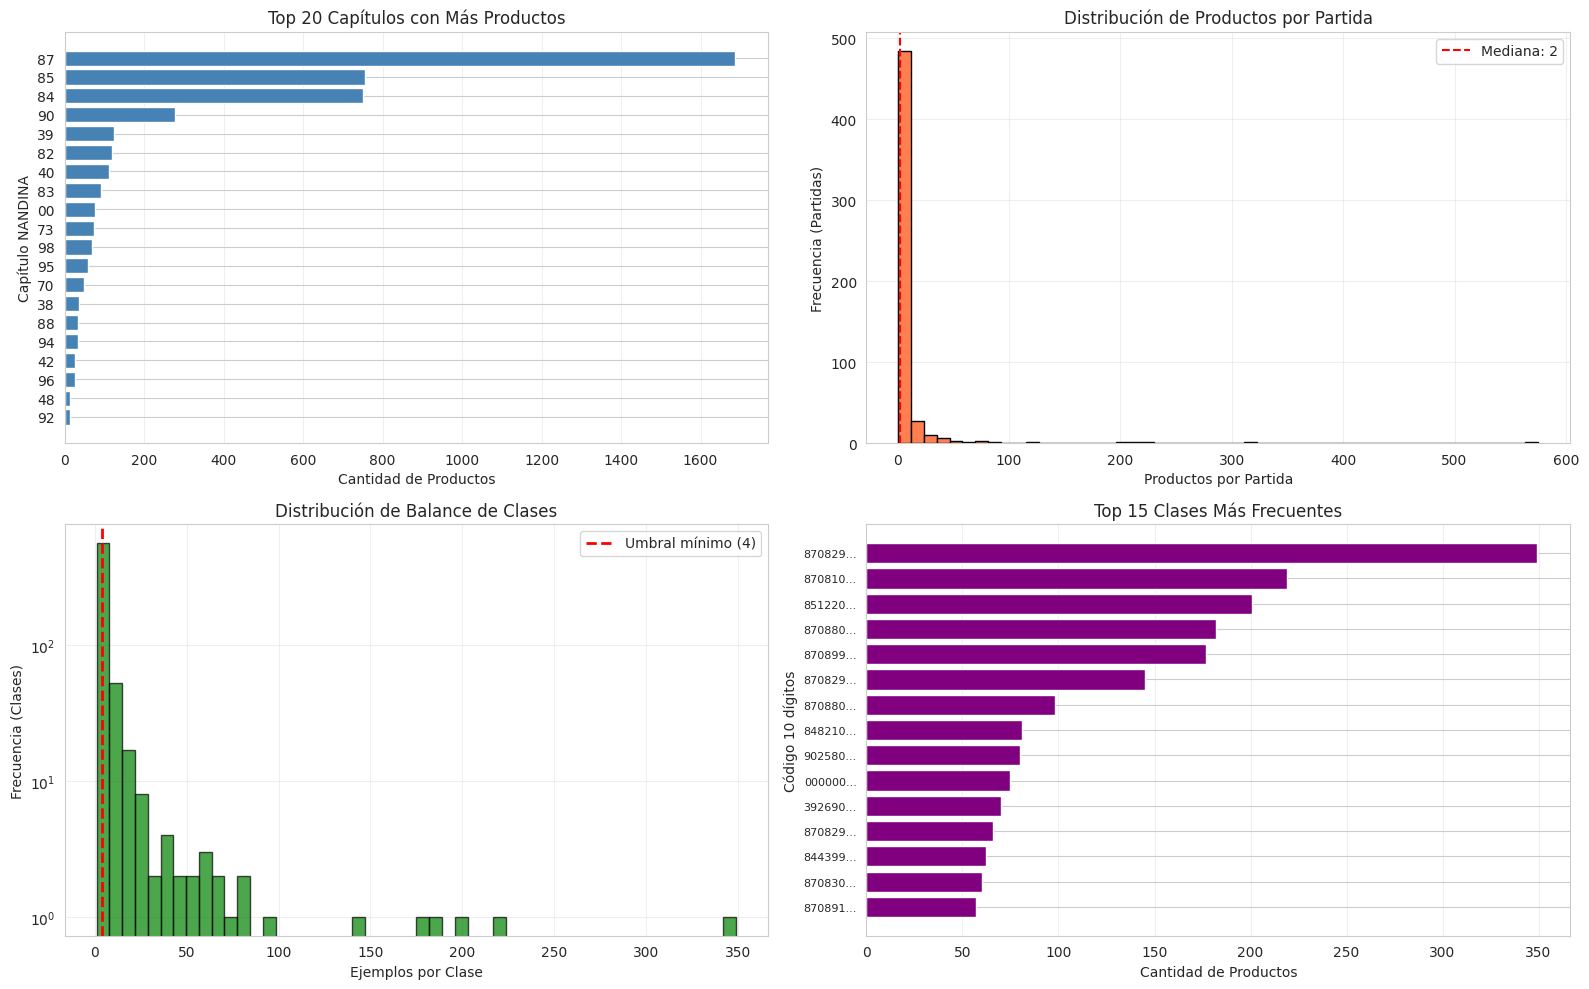


📈 Media: 8.39 productos/partida
📈 Mediana: 2 productos/partida


In [7]:
# Visualizar distribución de clases
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# 1. Top 20 capítulos más frecuentes
cap_counts = df_train['capitulo'].value_counts().head(20)
axes[0, 0].barh(range(len(cap_counts)), cap_counts.values, color='steelblue')
axes[0, 0].set_yticks(range(len(cap_counts)))
axes[0, 0].set_yticklabels(cap_counts.index)
axes[0, 0].set_xlabel('Cantidad de Productos')
axes[0, 0].set_ylabel('Capítulo NANDINA')
axes[0, 0].set_title('Top 20 Capítulos con Más Productos')
axes[0, 0].invert_yaxis()
axes[0, 0].grid(axis='x', alpha=0.3)

# 2. Distribución de productos por partida (histograma)
partida_counts = df_train['partida6'].value_counts()
axes[0, 1].hist(partida_counts.values, bins=50, color='coral', edgecolor='black')
axes[0, 1].set_xlabel('Productos por Partida')
axes[0, 1].set_ylabel('Frecuencia (Partidas)')
axes[0, 1].set_title('Distribución de Productos por Partida')
axes[0, 1].axvline(partida_counts.median(), color='red', linestyle='--', label=f'Mediana: {partida_counts.median():.0f}')
axes[0, 1].legend()
axes[0, 1].grid(alpha=0.3)

# 3. Distribución de ejemplos por clase (log scale)
axes[1, 0].hist(class_counts.values, bins=50, color='green', edgecolor='black', alpha=0.7)
axes[1, 0].set_xlabel('Ejemplos por Clase')
axes[1, 0].set_ylabel('Frecuencia (Clases)')
axes[1, 0].set_title('Distribución de Balance de Clases')
axes[1, 0].axvline(4, color='red', linestyle='--', linewidth=2, label='Umbral mínimo (4)')
axes[1, 0].set_yscale('log')
axes[1, 0].legend()
axes[1, 0].grid(alpha=0.3)

# 4. Top 15 clases más frecuentes
top_clases = class_counts.head(15)
axes[1, 1].barh(range(len(top_clases)), top_clases.values, color='purple')
axes[1, 1].set_yticks(range(len(top_clases)))
axes[1, 1].set_yticklabels([f"{c[:6]}..." for c in top_clases.index], fontsize=8)
axes[1, 1].set_xlabel('Cantidad de Productos')
axes[1, 1].set_ylabel('Código 10 dígitos')
axes[1, 1].set_title('Top 15 Clases Más Frecuentes')
axes[1, 1].invert_yaxis()
axes[1, 1].grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\n📈 Media: {partida_counts.mean():.2f} productos/partida")
print(f"📈 Mediana: {partida_counts.median():.0f} productos/partida")

### 2.3 Detección de Outliers


=== DETECCIÓN DE OUTLIERS (Clases con muchos ejemplos) ===

Q1 (percentil 25): 1.0
Q3 (percentil 75): 4.0
IQR: 3.0
Límite superior: 8.5

⚠️ Outliers detectados: 94 clases

Top 5 clases con más ejemplos (outliers):
  - 8708299090: 349 ejemplos - CUBIERTA TRASERA RETRACTIL...
  - 8708100000: 219 ejemplos - VINCHA SOPORTE - VINCHA PARACHOQUE DELANTERO LH AL...
  - 8512201000: 201 ejemplos - FARO DELANTERO RH...
  - 8708801000: 182 ejemplos - ROTULAS DIRECCION - KIT SUSPENSION ROUGH COUNTRY 2...
  - 8708999990: 177 ejemplos - TANQUE 10AN...

✓ DECISIÓN: NO eliminar outliers superiores
  Razón: Son clases legítimas con muchos productos reales
  Estrategia: Usar class_weight='balanced' en modelos para compensar


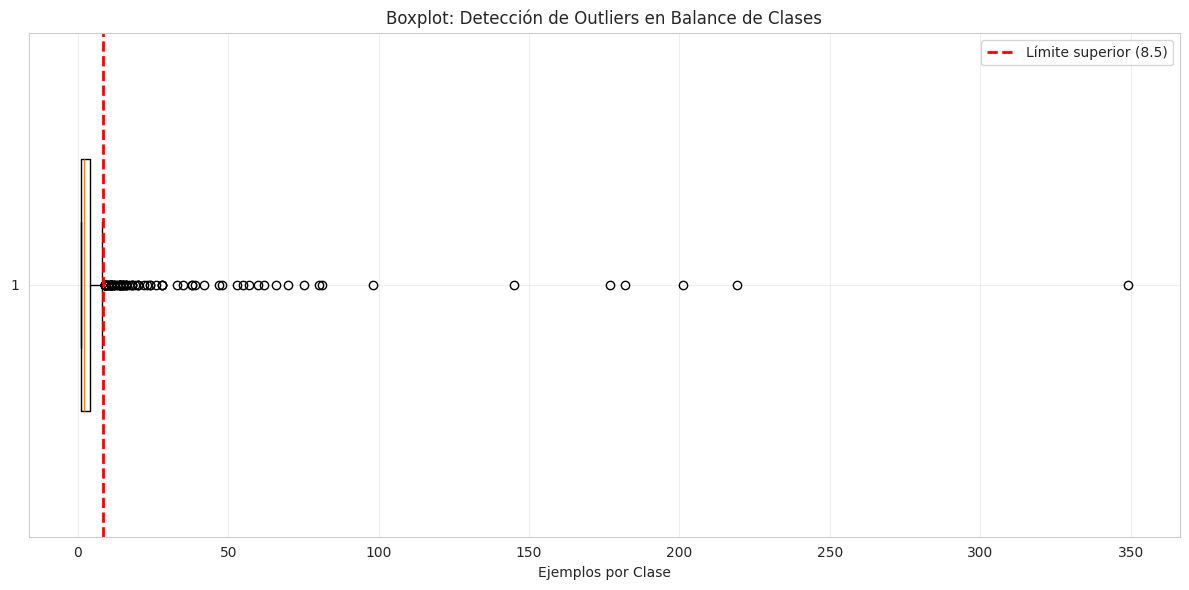

In [8]:
# OUTLIERS: Clases con cantidad de ejemplos anormalmente alta
# Usamos método IQR (Rango Intercuartílico)

Q1 = class_counts.quantile(0.25)
Q3 = class_counts.quantile(0.75)
IQR = Q3 - Q1

# Límites para outliers
limite_inferior = Q1 - 1.5 * IQR
limite_superior = Q3 + 1.5 * IQR

outliers_superiores = class_counts[class_counts > limite_superior]

print("\n=== DETECCIÓN DE OUTLIERS (Clases con muchos ejemplos) ===")
print(f"\nQ1 (percentil 25): {Q1:.1f}")
print(f"Q3 (percentil 75): {Q3:.1f}")
print(f"IQR: {IQR:.1f}")
print(f"Límite superior: {limite_superior:.1f}")

print(f"\n⚠️ Outliers detectados: {len(outliers_superiores)} clases")
print("\nTop 5 clases con más ejemplos (outliers):")
for codigo, count in outliers_superiores.head().items():
    desc = df_train[df_train['codigo10'] == codigo]['descripcion'].iloc[0]
    print(f"  - {codigo}: {count} ejemplos - {desc[:50]}...")

print(f"\n✓ DECISIÓN: NO eliminar outliers superiores")
print(f"  Razón: Son clases legítimas con muchos productos reales")
print(f"  Estrategia: Usar class_weight='balanced' en modelos para compensar")

# Visualizar boxplot
fig, ax = plt.subplots(figsize=(12, 6))
ax.boxplot([class_counts.values], vert=False, widths=0.5)
ax.set_xlabel('Ejemplos por Clase')
ax.set_title('Boxplot: Detección de Outliers en Balance de Clases')
ax.axvline(limite_superior, color='red', linestyle='--', linewidth=2, label=f'Límite superior ({limite_superior:.1f})')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### 2.4 Análisis de Longitud de Texto

In [9]:
# Analizar longitud de descripciones (importante para TF-IDF y embeddings)
df_train['longitud_texto'] = df_train['descripcion'].str.len()
df_train['num_palabras'] = df_train['descripcion'].str.split().str.len()

print("\n=== ANÁLISIS DE LONGITUD DE TEXTO ===")
print(f"\nCaracteres por descripción:")
print(f"  - Media: {df_train['longitud_texto'].mean():.1f}")
print(f"  - Mediana: {df_train['longitud_texto'].median():.0f}")
print(f"  - Mínimo: {df_train['longitud_texto'].min()}")
print(f"  - Máximo: {df_train['longitud_texto'].max()}")

print(f"\nPalabras por descripción:")
print(f"  - Media: {df_train['num_palabras'].mean():.1f}")
print(f"  - Mediana: {df_train['num_palabras'].median():.0f}")
print(f"  - Mínimo: {df_train['num_palabras'].min()}")
print(f"  - Máximo: {df_train['num_palabras'].max()}")

# Detectar descripciones muy cortas (outliers inferiores)
textos_cortos = df_train[df_train['num_palabras'] <= 2]
print(f"\n⚠️ Descripciones muy cortas (≤2 palabras): {len(textos_cortos)} ({len(textos_cortos)/len(df_train)*100:.1f}%)")
if len(textos_cortos) > 0:
    print("\nEjemplos:")
    for desc in textos_cortos['descripcion'].head(3):
        print(f"  - '{desc}'")

print(f"\n✓ DECISIÓN: Mantener textos cortos pero limpiar con preprocesamiento")


=== ANÁLISIS DE LONGITUD DE TEXTO ===

Caracteres por descripción:
  - Media: 26.2
  - Mediana: 23
  - Mínimo: 3.0
  - Máximo: 242.0

Palabras por descripción:
  - Media: 4.0
  - Mediana: 3
  - Mínimo: 1.0
  - Máximo: 37.0

⚠️ Descripciones muy cortas (≤2 palabras): 1153 (25.4%)

Ejemplos:
  - 'PASTA TERMICA'
  - 'PINTURAS'
  - 'COMPUESTOS QUIMICOS'

✓ DECISIÓN: Mantener textos cortos pero limpiar con preprocesamiento


## 3. PREPROCESAMIENTO DE DATOS

In [10]:
def limpiar_texto(texto):
    """
    Limpia y normaliza texto para TF-IDF.

    Pasos:
    1. Convertir a minúsculas
    2. Expandir abreviaciones comunes (kg → kilogramo)
    3. Eliminar caracteres especiales (mantener solo letras y espacios)
    4. Remover stopwords (palabras sin significado: 'de', 'la', 'el', etc.)
    5. Filtrar palabras cortas (< 3 caracteres)

    Razón: TF-IDF funciona mejor con texto limpio y significativo
    """
    if pd.isna(texto):
        return ''

    # Minúsculas
    texto = texto.lower()

    # Expandir abreviaciones comunes en productos
    texto = texto.replace(' kg ', ' kilogramo ')
    texto = texto.replace(' gr ', ' gramo ')
    texto = texto.replace(' ml ', ' mililitro ')
    texto = texto.replace(' lt ', ' litro ')

    # Solo letras españolas y espacios
    texto = re.sub(r'[^a-záéíóúñü\s]', ' ', texto)

    # Espacios múltiples a uno solo
    texto = re.sub(r'\s+', ' ', texto).strip()

    # Filtrar stopwords y palabras cortas
    palabras = [p for p in texto.split() if len(p) > 2 and p not in STOP_WORDS]

    return ' '.join(palabras)

# Aplicar limpieza
print("Limpiando texto...")
df_train['descripcion_limpia'] = df_train['descripcion'].apply(limpiar_texto)

# Mostrar ejemplos antes/después
print("\n=== EJEMPLOS DE LIMPIEZA ===")
for i in range(3):
    print(f"\nAntes: {df_train['descripcion'].iloc[i]}")
    print(f"Después: {df_train['descripcion_limpia'].iloc[i]}")

# Filtrar clases con pocos ejemplos (< 4)
# Razón: Necesitamos mínimo 4 para train/test split con stratify
class_counts = df_train['codigo10'].value_counts()
codigos_validos = class_counts[class_counts >= 4].index
df_model = df_train[df_train['codigo10'].isin(codigos_validos)].copy()

print(f"\n=== DATASET FILTRADO ===")
print(f"Antes: {len(df_train):,} productos, {df_train['codigo10'].nunique()} clases")
print(f"Después: {len(df_model):,} productos, {df_model['codigo10'].nunique()} clases")
print(f"Productos eliminados: {len(df_train) - len(df_model)} ({(len(df_train) - len(df_model))/len(df_train)*100:.1f}%)")

Limpiando texto...

=== EJEMPLOS DE LIMPIEZA ===

Antes: PACK HOJAS SECAS DECORATIVAS
Después: pack hojas secas decorativas

Antes: PASTA TERMICA
Después: pasta termica

Antes: REACTIVO DE LABORATORIO SOLUCION DE BETAINA PARA USO IN VITRO
Después: reactivo laboratorio solucion betaina uso vitro

=== DATASET FILTRADO ===
Antes: 4,547 productos, 669 clases
Después: 3,841 productos, 192 clases
Productos eliminados: 706 (15.5%)


## 4. FASE 1: ANALIZADOR MERCEOLÓGICO (LLM)

In [11]:
class AnalizadorMerceologicoMejorado:
    """
    Fase 1 del sistema híbrido: Usa LLM para análisis merceológico.

    Objetivo: Identificar los primeros 6 dígitos (partida NANDINA)
    Entrada: Descripción del producto
    Salida: Partida 6 dígitos + características técnicas + palabras clave

    Ventajas del LLM:
    - Comprende contexto semántico
    - Extrae características técnicas
    - Valida contra arancel oficial
    """
    def __init__(self, client, df_arancel, modelo='gpt-4o-mini', max_reintentos=2):
        self.client = client
        self.df_arancel = df_arancel
        self.modelo = modelo
        self.max_reintentos = max_reintentos

        # Validación: solo partidas que existen en el arancel oficial
        self.partidas_validas = set(df_arancel['partida6'].unique())

        # Ejemplos para few-shot learning (mejora accuracy del LLM)
        partidas_ej = df_arancel.groupby('partida6').first()['C6_Description'].sample(
            min(40, df_arancel['partida6'].nunique()), random_state=42
        ).to_dict()
        self.ejemplos = '\n'.join([f"{k}: {v}" for k, v in list(partidas_ej.items())[:25]])

    def analizar_producto(self, descripcion_producto):
        """
        Analiza producto con LLM.

        Incluye:
        - Retry logic: Hasta 2 intentos si falla
        - Validación: Partida debe existir en arancel
        - Fallback: Si partida no existe, busca similar con prefijo 4 dígitos
        - Extracción enriquecida: características + keywords
        """
        for intento in range(self.max_reintentos):
            # Prompt engineering: Instrucciones claras + ejemplos + formato JSON
            prompt = f"""Clasificador NANDINA ECUADOR con análisis técnico.

PRODUCTO: {descripcion_producto}

INSTRUCCIONES:
1. Identifica Capítulo (2 dígitos)
2. Identifica Partida (2 dígitos)
3. Identifica Subpartida NANDINA Ecuador (2 dígitos)
4. Extrae características técnicas relevantes (material, tamaño, uso, tecnología)
5. Genera palabras clave específicas del producto

EJEMPLOS ECUADOR:
{self.ejemplos}

JSON:
{{
  "partida_6_digitos": "XXXXXX",
  "razonamiento": "Breve explicación",
  "caracteristicas": {{
    "material": "plástico/metal/textil/etc",
    "uso_aplicacion": "uso principal",
    "especificaciones": "tamaño/voltaje/peso/etc"
  }},
  "palabras_clave": ["palabra1", "palabra2", "palabra3"]
}}

IMPORTANTE: 6 dígitos consecutivos válidos Ecuador."""

            try:
                # Llamada a OpenAI con temperature baja (más determinista)
                response = self.client.chat.completions.create(
                    model=self.modelo,
                    messages=[
                        {"role": "system", "content": "Experto en clasificación arancelaria NANDINA."},
                        {"role": "user", "content": prompt}
                    ],
                    temperature=0.1,  # Bajo = más consistente
                    response_format={"type": "json_object"}  # Forzar respuesta JSON
                )

                resultado = json.loads(response.choices[0].message.content)
                partida6 = resultado.get('partida_6_digitos', '').strip()
                razonamiento = resultado.get('razonamiento', '')
                caracteristicas = resultado.get('caracteristicas', {})
                palabras_clave = resultado.get('palabras_clave', [])

                # Validar formato (6 dígitos numéricos)
                if not re.match(r'^\d{6}$', partida6):
                    continue

                # Validar contra arancel oficial
                if partida6 in self.partidas_validas:
                    return {
                        'partida6': partida6,
                        'razonamiento': razonamiento,
                        'caracteristicas': caracteristicas,
                        'palabras_clave': palabras_clave
                    }

                # Fallback: Buscar partida similar con prefijo de 4 dígitos
                cercanas = [p for p in self.partidas_validas if p.startswith(partida6[:4])]
                if cercanas:
                    partida6 = cercanas[0]
                    razonamiento += f" (Ajustada: {partida6})"
                    return {
                        'partida6': partida6,
                        'razonamiento': razonamiento,
                        'caracteristicas': caracteristicas,
                        'palabras_clave': palabras_clave
                    }

            except Exception as e:
                if intento == self.max_reintentos - 1:
                    return {'error': str(e)}

        return {'error': 'No válida'}

    def obtener_candidatos(self, partida6):
        """
        Filtra arancel oficial para obtener solo códigos de 10 dígitos
        que pertenecen a la partida de 6 dígitos identificada.

        Ejemplo: partida6='852872' → retorna ~41 códigos posibles
        """
        if partida6 is None:
            return pd.DataFrame()
        return self.df_arancel[self.df_arancel['partida6'] == partida6].copy()

if OPENAI_API_KEY != 'tu-api-key-aqui':
    analizador = AnalizadorMerceologicoMejorado(client, df_arancel)
    print('✓ Analizador LLM configurado')

✓ Analizador LLM configurado


## 5. FASE 2: CLASIFICADORES ML Y EMBEDDINGS

### 5.1 Clasificador por Embeddings Semánticos

In [12]:
class ClasificadorEmbeddings:
    """
    Clasificador basado en similitud semántica con embeddings.

    Ventajas:
    - Captura significado semántico ("televisor" ≈ "TV" ≈ "pantalla")
    - Funciona bien con pocos ejemplos
    - No requiere entrenamiento

    Desventajas:
    - Más lento que TF-IDF
    - Requiere modelo grande (~120MB)

    Usado cuando:
    - Pocos candidatos (≤5)
    - Solo 1 clase en dataset (ML no aplicable)
    - Como complemento en ensemble
    """
    def __init__(self, modelo_embeddings):
        self.modelo = modelo_embeddings
        self.embeddings_cache = {}

    def clasificar_por_similitud(self, descripcion, candidatos_df, palabras_clave=None, top_k=5):
        """
        Clasifica por similitud coseno entre embeddings.

        Proceso:
        1. Enriquecer descripción con keywords del LLM
        2. Generar embedding del producto (384 dims)
        3. Generar embeddings de todos los candidatos
        4. Calcular similitud coseno
        5. Retornar top-K más similares
        """
        if len(candidatos_df) == 0:
            return []

        # Enriquecer con palabras clave del LLM (mejora precisión)
        desc_enriquecida = descripcion
        if palabras_clave:
            desc_enriquecida += ' ' + ' '.join(palabras_clave)

        # Generar embeddings (vectores densos)
        emb_producto = self.modelo.encode(desc_enriquecida, convert_to_tensor=False)
        descripciones = candidatos_df['C10_Description'].tolist()
        embs_candidatos = self.modelo.encode(descripciones, convert_to_tensor=False)

        # Similitud coseno: mide ángulo entre vectores (0=opuesto, 1=idéntico)
        similitudes = pairwise.cosine_similarity([emb_producto], embs_candidatos)[0]

        # Top-K
        top_indices = np.argsort(similitudes)[:-top_k-1:-1]

        resultados = []
        for idx in top_indices:
            resultados.append({
                'codigo': candidatos_df.iloc[idx]['codigo10'],
                'similitud': similitudes[idx],
                'descripcion': candidatos_df.iloc[idx]['C10_Description']
            })

        return resultados

clasificador_embeddings = ClasificadorEmbeddings(modelo_embeddings)
print('✓ Clasificador Embeddings configurado')

✓ Clasificador Embeddings configurado


### 5.2 Clasificador ML (TF-IDF + Modelos)

In [28]:
# ==============================================================================
# CLASIFICADOR ML ROBUSTO (V3 - Fix Binario y XGBoost)
# ==============================================================================
from sklearn.calibration import CalibratedClassifierCV
from sklearn.svm import LinearSVC
from xgboost import XGBClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, top_k_accuracy_score
from imblearn.over_sampling import SMOTE
import pandas as pd
import numpy as np

class ClasificadorML:
    def __init__(self, random_state=42):
        self.random_state = random_state
        self.vectorizador = None
        self.le = LabelEncoder()
        self.modelos = {}
        self.mejor_modelo = None
        self.mejor_modelo_nombre = None
        self.metricas = {}

    def entrenar(self, df_train_input, mostrar_progreso=True):
        X_text = df_train_input['descripcion_limpia'].astype(str)
        y = df_train_input['codigo10'].astype(str)

        # Validar que haya al menos 2 clases para entrenar
        if y.nunique() < 2:
            print("Error: Se necesitan al menos 2 clases para entrenar.")
            return None

        # 1. Split Estratificado (con manejo de errores si hay clases con 1 solo ejemplo)
        try:
            X_train, X_test, y_train, y_test = train_test_split(
                X_text, y, test_size=0.2, random_state=self.random_state, stratify=y
            )
        except ValueError:
            # Fallback sin stratify si hay clases con 1 solo miembro
            X_train, X_test, y_train, y_test = train_test_split(
                X_text, y, test_size=0.2, random_state=self.random_state
            )

        # 2. Codificación
        self.le.fit(y)
        y_train_enc = self.le.transform(y_train)
        y_test_enc = self.le.transform(y_test)

        # 3. Vectorización
        self.vectorizador = TfidfVectorizer(max_features=5000, ngram_range=(1, 3), min_df=2, sublinear_tf=True)
        X_train_vec = self.vectorizador.fit_transform(X_train)
        X_test_vec = self.vectorizador.transform(X_test)

        # 4. SMOTE (Seguro)
        try:
            y_counts = pd.Series(y_train_enc).value_counts()
            if len(y_counts) > 1 and min(y_counts) > 1: # Solo si es posible hacer vecinos
                k_neigh = max(1, min(3, min(y_counts) - 1))
                smote = SMOTE(random_state=self.random_state, k_neighbors=k_neigh)
                X_train_vec, y_train_enc = smote.fit_resample(X_train_vec, y_train_enc)
        except Exception:
            pass # Ignorar fallo de SMOTE en datasets muy pequeños

        # 5. Modelos
        svc_calibrado = CalibratedClassifierCV(estimator=LinearSVC(class_weight='balanced', random_state=self.random_state), method='sigmoid')

        modelos_config = {
            'Logistic Regression': LogisticRegression(max_iter=1000, C=2.0, solver='saga', class_weight='balanced', random_state=self.random_state, n_jobs=-1),
            'Linear SVC (Calibrado)': svc_calibrado,
            'Random Forest': RandomForestClassifier(n_estimators=200, class_weight='balanced', random_state=self.random_state, n_jobs=-1),
            # FIX XGBOOST: Quitamos objective='multi:softprob' para que detecte auto si es binario o multi
            'XGBoost': XGBClassifier(n_estimators=150, learning_rate=0.1, max_depth=6, subsample=0.8, random_state=self.random_state, n_jobs=-1, verbosity=0)
        }

        resultados = []
        n_clases = len(self.le.classes_)

        for nombre, modelo in modelos_config.items():
            if mostrar_progreso: print(f"Entrenando {nombre}...")

            try:
                modelo.fit(X_train_vec, y_train_enc)

                # Evaluación robusta
                acc = 0.0
                top3 = 0.0

                if hasattr(modelo, 'predict_proba'):
                    y_proba = modelo.predict_proba(X_test_vec)
                    y_pred_enc = np.argmax(y_proba, axis=1)
                    acc = accuracy_score(y_test_enc, y_pred_enc)

                    # FIX TOP-K: Solo calcular si hay suficientes clases y no es binario conflictivo
                    if n_clases > 2:
                        k3 = min(3, n_clases)
                        top3 = top_k_accuracy_score(y_test_enc, y_proba, k=k3, labels=range(n_clases))
                    else:
                        top3 = acc # En binario, Top-3 no tiene sentido (es igual a Accuracy o 100%)
                else:
                    y_pred_enc = modelo.predict(X_test_vec)
                    acc = accuracy_score(y_test_enc, y_pred_enc)
                    top3 = acc

                self.modelos[nombre] = modelo
                self.metricas[nombre] = {'accuracy': acc, 'top3': top3, 'top5': top3} # Simplificado
                resultados.append({'Modelo': nombre, 'Accuracy': f"{acc*100:.2f}%", 'Top-3': f"{top3*100:.2f}%"})

            except Exception as e:
                if mostrar_progreso: print(f"  -> Skip {nombre}: {str(e)}")

        # Seleccionar ganador (si alguno funcionó)
        if self.metricas:
            mejor = max(self.metricas.items(), key=lambda x: x[1]['accuracy'])
            self.mejor_modelo_nombre = mejor[0]
            self.mejor_modelo = self.modelos[self.mejor_modelo_nombre]
            self.X_test_vec = X_test_vec
            self.y_test = y_test
            self.y_test_enc = y_test_enc
            return pd.DataFrame(resultados)
        else:
            return pd.DataFrame() # Vacío si todo falló

    def predecir(self, descripcion, top_k=5):
        if not self.mejor_modelo: return []
        desc_limpia = limpiar_texto(descripcion)
        X_vec = self.vectorizador.transform([desc_limpia])

        if hasattr(self.mejor_modelo, 'predict_proba'):
            probas = self.mejor_modelo.predict_proba(X_vec)[0]
            top_indices = np.argsort(probas)[:-top_k-1:-1]
            resultados = []
            for idx in top_indices:
                codigo_real = self.le.inverse_transform([idx])[0]
                resultados.append({'codigo': codigo_real, 'probabilidad': probas[idx]})
            return resultados
        else:
            pred_enc = self.mejor_modelo.predict(X_vec)[0]
            codigo_real = self.le.inverse_transform([pred_enc])[0]
            return [{'codigo': codigo_real, 'probabilidad': 1.0}]

print('✓ ClasificadorML V3 (Robusto) cargado')

✓ ClasificadorML V3 (Robusto) cargado


### 5.3 Entrenamiento Global

In [29]:
# Entrenar clasificador global (todos los datos)
# Este modelo sirve como baseline y para comparación

print('Entrenando clasificador global...\n')
clasificador = ClasificadorML(random_state=RANDOM_STATE)
tabla = clasificador.entrenar(df_model, mostrar_progreso=True)
print('\n' + tabla.to_string(index=False))

Entrenando clasificador global...

Entrenando Logistic Regression...
Entrenando Linear SVC (Calibrado)...
Entrenando Random Forest...
Entrenando XGBoost...

                Modelo Accuracy  Top-3
   Logistic Regression   65.02% 79.58%
Linear SVC (Calibrado)   65.28% 77.63%
         Random Forest   62.68% 77.89%
               XGBoost   60.99% 71.13%


## 6. EVALUACIÓN DEL CLASIFICADOR GLOBAL

### 6.1 Matriz de Confusión

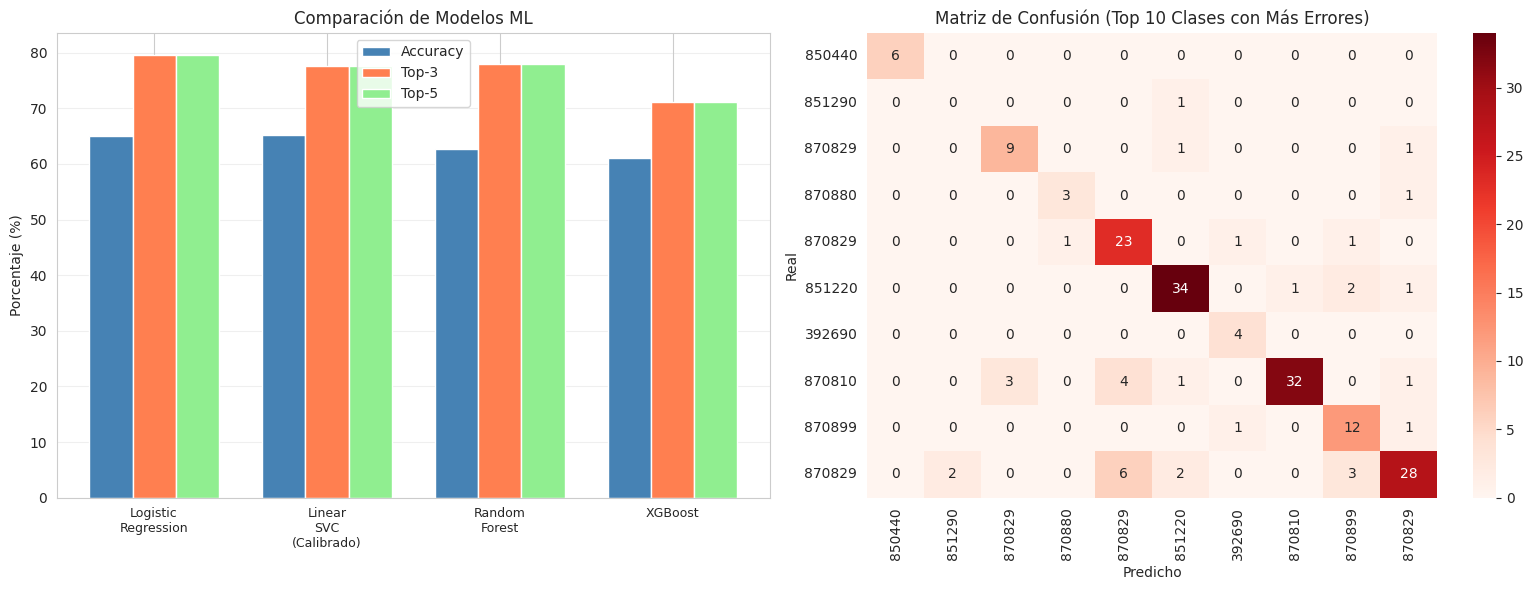


📊 Interpretación:
- Diagonal: Predicciones correctas
- Valores altos fuera de diagonal: Confusión entre clases
- Mejor modelo: Linear SVC (Calibrado)


In [30]:
# ==============================================================================
# 6.1 EVALUACIÓN GLOBAL Y MATRIZ DE CONFUSIÓN (CORREGIDO)
# ==============================================================================
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
import numpy as np

# Matriz de confusión: visualiza errores de clasificación
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# 1. Comparación de modelos
modelos_nombres = list(clasificador.metricas.keys())
accs = [clasificador.metricas[m]['accuracy'] * 100 for m in modelos_nombres]
top3s = [clasificador.metricas[m]['top3'] * 100 for m in modelos_nombres]
top5s = [clasificador.metricas[m]['top5'] * 100 for m in modelos_nombres]

x = np.arange(len(modelos_nombres))
width = 0.25
axes[0].bar(x - width, accs, width, label='Accuracy', color='steelblue')
axes[0].bar(x, top3s, width, label='Top-3', color='coral')
axes[0].bar(x + width, top5s, width, label='Top-5', color='lightgreen')
axes[0].set_ylabel('Porcentaje (%)')
axes[0].set_title('Comparación de Modelos ML')
axes[0].set_xticks(x)
axes[0].set_xticklabels([m.replace(' ', '\n') for m in modelos_nombres], fontsize=9)
axes[0].legend()
axes[0].grid(axis='y', alpha=0.3)

# 2. Matriz de confusión (top 10 clases con más errores)
# PASO CRÍTICO: Predecir números y convertirlos a texto (Strings)
y_pred_int = clasificador.mejor_modelo.predict(clasificador.X_test_vec)
y_pred_test = clasificador.le.inverse_transform(y_pred_int) # <--- CORRECCIÓN AQUÍ

# Ahora ambos son texto, no habrá error de tipos
clases_unicas = sorted(list(set(clasificador.y_test) | set(y_pred_test)))
cm = confusion_matrix(clasificador.y_test, y_pred_test, labels=clases_unicas)

# Identificar clases con más errores
errores_por_clase = cm.sum(axis=1) - np.diag(cm)
top_errores_idx = np.argsort(errores_por_clase)[-10:]
cm_top = cm[top_errores_idx][:, top_errores_idx]
clases_top = [clases_unicas[i] for i in top_errores_idx]

sns.heatmap(cm_top, annot=True, fmt='d', cmap='Reds', ax=axes[1], cbar=True,
            xticklabels=[c[:6] for c in clases_top],
            yticklabels=[c[:6] for c in clases_top])
axes[1].set_title('Matriz de Confusión (Top 10 Clases con Más Errores)')
axes[1].set_xlabel('Predicho')
axes[1].set_ylabel('Real')

plt.tight_layout()
plt.show()

print("\n📊 Interpretación:")
print("- Diagonal: Predicciones correctas")
print("- Valores altos fuera de diagonal: Confusión entre clases")
print(f"- Mejor modelo: {clasificador.mejor_modelo_nombre}")

### 6.2 Accuracy por Capítulo


=== EVALUACIÓN DE PRECISIÓN POR PARTIDA ===

Seleccionando partidas con >20 productos para evaluación...

Partida  Productos  Clases                 Modelo  Accuracy    Top-3
 870829        571       4 Linear SVC (Calibrado)  0.843478 1.000000
 870880        315       3    Logistic Regression  0.857143 1.000000
 870899        221       5          Random Forest  0.911111 1.000000
 851220        207       2          Random Forest  1.000000 1.000000
 870830        123       3          Random Forest  0.960000 1.000000
 902580         87       2 Linear SVC (Calibrado)  0.944444 0.944444
 850440         81       2          Random Forest  0.823529 0.823529

📊 Accuracy promedio: 90.57%


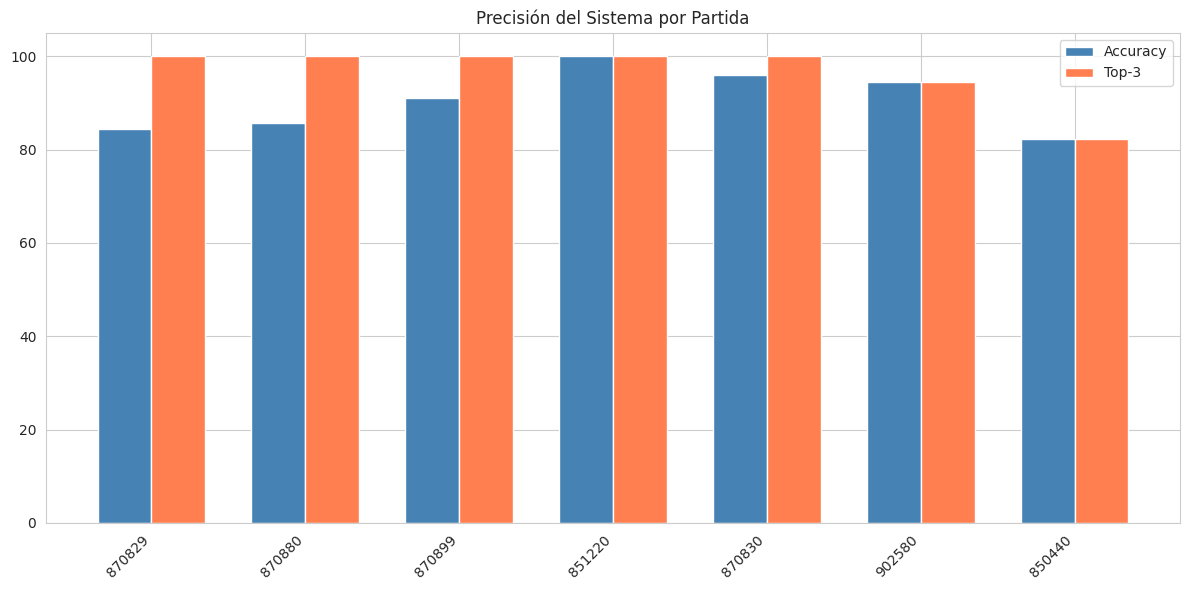

In [31]:
print("\n=== EVALUACIÓN DE PRECISIÓN POR PARTIDA ===")
print("\nSeleccionando partidas con >20 productos para evaluación...\n")

partidas_grandes = df_model['partida6'].value_counts()
partidas_eval = partidas_grandes[partidas_grandes > 20].head(10).index.tolist()

resultados_eval = []

for partida in partidas_eval:
    df_part = df_model[df_model['partida6'] == partida].copy()
    n_productos = len(df_part)
    n_clases = df_part['codigo10'].nunique()

    # Entrenar modelo específico para esta partida
    if n_clases > 1 and n_productos >= 10:
        clf_part = ClasificadorML(random_state=RANDOM_STATE)
        # Entrenar silenciando errores
        clf_part.entrenar(df_part, mostrar_progreso=False)

        # Verificar si se entrenó algún modelo exitosamente
        if clf_part.mejor_modelo_nombre:
            mejor_metrica = clf_part.metricas[clf_part.mejor_modelo_nombre]

            resultados_eval.append({
                'Partida': partida,
                'Productos': n_productos,
                'Clases': n_clases,
                'Modelo': clf_part.mejor_modelo_nombre,
                'Accuracy': mejor_metrica['accuracy'],
                'Top-3': mejor_metrica['top3']
            })
        else:
            print(f"⚠️ Partida {partida}: Falló el entrenamiento (datos insuficientes o desbalance extremo)")

df_resultados = pd.DataFrame(resultados_eval)

if not df_resultados.empty:
    print(df_resultados.to_string(index=False))
    print(f"\n📊 Accuracy promedio: {df_resultados['Accuracy'].mean()*100:.2f}%")

    # Visualización
    fig, ax = plt.subplots(figsize=(12, 6))
    x = np.arange(len(df_resultados))
    width = 0.35
    ax.bar(x - width/2, df_resultados['Accuracy']*100, width, label='Accuracy', color='steelblue')
    ax.bar(x + width/2, df_resultados['Top-3']*100, width, label='Top-3', color='coral')
    ax.set_title('Precisión del Sistema por Partida')
    ax.set_xticks(x)
    ax.set_xticklabels(df_resultados['Partida'], rotation=45, ha='right')
    ax.legend()
    plt.tight_layout()
    plt.show()
else:
    print("No se pudieron obtener resultados para las partidas seleccionadas.")

### 6.3 Reporte de Clasificación

In [32]:
# ==============================================================================
# 6.3 REPORTE DE CLASIFICACIÓN CORREGIDO
# ==============================================================================
from sklearn.metrics import classification_report

# Limitado a top 10 clases para visualización
top_10_clases = df_model['codigo10'].value_counts().head(10).index.tolist()
mask = clasificador.y_test.isin(top_10_clases)

if mask.sum() > 0:
    y_test_top10 = clasificador.y_test[mask]

    # 1. Predecir números
    y_pred_int = clasificador.mejor_modelo.predict(clasificador.X_test_vec[mask.values])

    # 2. Convertir números a texto (CORRECCIÓN IMPORTANTE)
    y_pred_top10 = clasificador.le.inverse_transform(y_pred_int)

    print("\n=== REPORTE DE CLASIFICACIÓN (Top 10 Clases) ===")
    # Usamos 'labels' para asegurar que solo reporte estas clases específicas
    print(classification_report(y_test_top10, y_pred_top10, labels=top_10_clases, zero_division=0))

    print("\n📊 Métricas explicadas:")
    print("- Precision: De todos los predichos como X, ¿cuántos son realmente X?")
    print("- Recall: De todos los reales X, ¿cuántos predije como X?")
    print("- F1-Score: Media armónica de precision y recall")
    print("- Support: Número de ejemplos reales de cada clase")


=== REPORTE DE CLASIFICACIÓN (Top 10 Clases) ===
              precision    recall  f1-score   support

  8708299090       0.88      0.40      0.55        70
  8708100000       0.97      0.73      0.83        44
  8512201000       0.92      0.85      0.88        40
  8708801000       1.00      0.94      0.97        36
  8708999990       0.67      0.34      0.45        35
  8708292000       0.70      0.79      0.74        29
  8708802010       1.00      0.95      0.97        20
  8482100000       0.94      0.94      0.94        16
  9025804900       0.76      0.81      0.79        16
  0000000nan       0.68      1.00      0.81        15

   micro avg       0.86      0.70      0.77       321
   macro avg       0.85      0.78      0.79       321
weighted avg       0.87      0.70      0.75       321


📊 Métricas explicadas:
- Precision: De todos los predichos como X, ¿cuántos son realmente X?
- Recall: De todos los reales X, ¿cuántos predije como X?
- F1-Score: Media armónica de precision

### 6.4 Análisis R² (No Aplicable)

**Nota importante:** R² (coeficiente de determinación) es una métrica para **regresión** (predicción de valores continuos), no para **clasificación** (predicción de categorías).

Nuestro problema es **clasificación multiclase** con variable objetivo categórica (`codigo10`), por lo tanto:
- ❌ R² no es aplicable
- ✅ Usamos: Accuracy, Precision, Recall, F1-Score, Top-K Accuracy

Si quisiéramos un análisis similar a R² para clasificación, podríamos usar:
- **Cohen's Kappa**: Mide acuerdo entre predicciones y realidad (ajustado por azar)
- **Matthews Correlation Coefficient (MCC)**: Correlación entre predicciones y realidad

In [33]:
# ==============================================================================
# 6.4 COHEN'S KAPPA CORREGIDO
# ==============================================================================
from sklearn.metrics import cohen_kappa_score

# 1. Predecir números
y_pred_int = clasificador.mejor_modelo.predict(clasificador.X_test_vec)

# 2. Convertir números a texto (CORRECCIÓN IMPORTANTE)
y_pred_all = clasificador.le.inverse_transform(y_pred_int)

# Ahora comparamos Texto vs Texto
kappa = cohen_kappa_score(clasificador.y_test, y_pred_all)

print("\n=== COHEN'S KAPPA (Alternativa a R² para clasificación) ===")
print(f"Cohen's Kappa: {kappa:.4f}")
print("\nInterpretación:")
print("  < 0.00: Acuerdo peor que el azar")
print("  0.00-0.20: Acuerdo leve")
print("  0.21-0.40: Acuerdo razonable")
print("  0.41-0.60: Acuerdo moderado")
print("  0.61-0.80: Acuerdo sustancial")
print("  0.81-1.00: Acuerdo casi perfecto")

if kappa < 0.20:
    nivel = "leve ⚠️"
elif kappa < 0.40:
    nivel = "razonable"
elif kappa < 0.60:
    nivel = "moderado ✓"
elif kappa < 0.80:
    nivel = "sustancial ✓✓"
else:
    nivel = "casi perfecto ✓✓✓"

print(f"\n➜ Resultado: Acuerdo {nivel}")


=== COHEN'S KAPPA (Alternativa a R² para clasificación) ===
Cohen's Kappa: 0.6451

Interpretación:
  < 0.00: Acuerdo peor que el azar
  0.00-0.20: Acuerdo leve
  0.21-0.40: Acuerdo razonable
  0.41-0.60: Acuerdo moderado
  0.61-0.80: Acuerdo sustancial
  0.81-1.00: Acuerdo casi perfecto

➜ Resultado: Acuerdo sustancial ✓✓


## 7. SISTEMA HÍBRIDO COMPLETO

In [34]:
class SistemaHibridoMejorado:
    """
    Sistema híbrido completo: LLM + ML + Embeddings

    Estrategia adaptativa:
    1. ≤5 candidatos → Solo Embeddings (rápido y preciso)
    2. >5 candidatos + 1 clase → Solo Embeddings (ML no aplicable)
    3. >5 candidatos + >1 clase → Ensemble ML + Embeddings

    Ensemble: Combina scores de ML (TF-IDF) y Embeddings (semántico)
    - peso_ml: Peso del modelo ML (default 50%)
    - peso_emb: Peso de embeddings (default 50%)

    Ventajas:
    - ML: Aprende patrones del dataset histórico
    - Embeddings: Captura similitud semántica directa
    - Ensemble: Combina fortalezas de ambos
    """
    def __init__(self, analizador_llm, clasificador_ml, clasificador_emb, df_arancel, df_train):
        self.analizador = analizador_llm
        self.clf_ml = clasificador_ml
        self.clf_emb = clasificador_emb
        self.df_arancel = df_arancel
        self.df_train = df_train
        self.cache_ml = {}  # Cache de modelos entrenados por partida
        self.peso_ml = 0.5
        self.peso_emb = 0.5

    def clasificar(self, descripcion, top_k=5, verbose=True):
        """
        Clasificación completa en 2 fases.

        Fase 1: LLM identifica partida 6 dígitos
        Fase 2: ML/Embeddings clasifican código 10 dígitos
        """
        if verbose:
            print(f"\n{'='*70}\nProducto: {descripcion}\n{'='*70}\n")

        # FASE 1: Análisis merceológico con LLM
        if verbose:
            print('[FASE 1] LLM (análisis merceológico)...')

        resultado_llm = self.analizador.analizar_producto(descripcion)

        if 'error' in resultado_llm:
            return {'exito': False, 'error': 'LLM falló', 'razonamiento': resultado_llm['error']}

        partida6 = resultado_llm['partida6']
        palabras_clave = resultado_llm.get('palabras_clave', [])
        caracteristicas = resultado_llm.get('caracteristicas', {})

        if verbose:
            print(f"  Partida: {partida6}")
            print(f"  Razón: {resultado_llm['razonamiento'][:80]}...")
            if palabras_clave:
                print(f"  Keywords: {', '.join(palabras_clave[:5])}")

        candidatos = self.analizador.obtener_candidatos(partida6)

        if len(candidatos) == 0:
            return {'exito': False, 'error': f'Sin candidatos {partida6}', 'partida6': partida6}

        if verbose:
            print(f"  Candidatos: {len(candidatos)}\n")

        # FASE 2: Estrategia adaptativa

        # Estrategia 1: Pocos candidatos (≤5) → Solo Embeddings
        if len(candidatos) <= 5:
            if verbose:
                print('[FASE 2] Embeddings (pocos candidatos)...')

            resultados_emb = self.clf_emb.clasificar_por_similitud(
                descripcion, candidatos, palabras_clave, top_k
            )

            resultados = []
            for r in resultados_emb:
                info = candidatos[candidatos['codigo10'] == r['codigo']].iloc[0]
                resultados.append({
                    'codigo': r['codigo'],
                    'descripcion': info['C10_Description'],
                    'capitulo': info['C2_Description'],
                    'probabilidad': r['similitud'],
                    'metodo': 'Embeddings'
                })

            return {'exito': True, 'partida6': partida6, 'predicciones': resultados}

        # Estrategia 2: Muchos candidatos
        if verbose:
            print('[FASE 2] ML + Embeddings (ensemble)...')

        df_p = self.df_train[self.df_train['partida6'] == partida6].copy()
        n_clases = df_p['codigo10'].nunique()

        # Fallback: Solo 1 clase o pocos datos → Solo Embeddings
        if len(df_p) < 10 or n_clases == 1:
            if verbose:
                print(f"  Solo {n_clases} clase(s), usando Embeddings...")

            resultados_emb = self.clf_emb.clasificar_por_similitud(
                descripcion, candidatos, palabras_clave, top_k
            )

            resultados = []
            for r in resultados_emb:
                info = candidatos[candidatos['codigo10'] == r['codigo']].iloc[0]
                resultados.append({
                    'codigo': r['codigo'],
                    'descripcion': info['C10_Description'],
                    'capitulo': info['C2_Description'],
                    'probabilidad': r['similitud'],
                    'metodo': 'Embeddings (fallback)'
                })

            return {'exito': True, 'partida6': partida6, 'predicciones': resultados}

        # Estrategia 3: Ensemble ML + Embeddings

        # Entrenar/recuperar modelo ML específico para esta partida
        if partida6 not in self.cache_ml:
            clf = ClasificadorML(random_state=RANDOM_STATE)
            clf.entrenar(df_p, mostrar_progreso=verbose)
            self.cache_ml[partida6] = clf
        else:
            clf = self.cache_ml[partida6]
            if verbose:
                print(f"  ML: cache")

        preds_ml = clf.predecir(descripcion, top_k=top_k)

        if verbose:
            print(f"  Embeddings...")

        preds_emb = self.clf_emb.clasificar_por_similitud(
            descripcion, candidatos, palabras_clave, top_k
        )

        # ENSEMBLE: Combinar scores normalizados
        scores_combinados = {}

        # Scores de ML (ya son probabilidades 0-1)
        for p in preds_ml:
            scores_combinados[p['codigo']] = p['probabilidad'] * self.peso_ml

        # Scores de Embeddings (normalizar similitudes a 0-1)
        max_sim = max([p['similitud'] for p in preds_emb]) if preds_emb else 1.0
        for p in preds_emb:
            sim_norm = p['similitud'] / max_sim if max_sim > 0 else 0
            scores_combinados[p['codigo']] = scores_combinados.get(p['codigo'], 0) + sim_norm * self.peso_emb

        # Top-K combinado
        top_codigos = sorted(scores_combinados.items(), key=lambda x: x[1], reverse=True)[:top_k]

        resultados = []
        for codigo, score in top_codigos:
            info = self.df_arancel[self.df_arancel['codigo10'] == codigo]
            if len(info) > 0:
                info = info.iloc[0]
                resultados.append({
                    'codigo': codigo,
                    'descripcion': info['C10_Description'],
                    'capitulo': info['C2_Description'],
                    'probabilidad': score,
                    'metodo': f'Ensemble (ML:{self.peso_ml*100:.0f}% + Emb:{self.peso_emb*100:.0f}%)'
                })

        if verbose:
            print(f"  OK\n")

        return {'exito': True, 'partida6': partida6, 'predicciones': resultados, 'caracteristicas_llm': caracteristicas}

if OPENAI_API_KEY != 'tu-api-key-aqui':
    sistema = SistemaHibridoMejorado(analizador, clasificador, clasificador_embeddings, df_arancel, df_model)
    print('✓ Sistema Híbrido configurado')

✓ Sistema Híbrido configurado


## 8. PRUEBAS DEL SISTEMA

In [37]:
# ==============================================================================
# 8. PRUEBAS DE INFERENCIA (VISUALIZACIÓN TOP-3)
# ==============================================================================

if OPENAI_API_KEY != 'tu-api-key-aqui':
    print(f"\n{'='*60}")
    print(" PRUEBAS DE CLASIFICACIÓN (HUMAN-IN-THE-LOOP)")
    print(f"{'='*60}")

    casos = [
        'Gafas de sol',
        'Televisor de 32 pulgadas',
        'Laptop Dell i7 16GB RAM'
    ]

    for caso in casos:
        # Solicitamos top_k=3 para ver las opciones
        resultado = sistema.clasificar(caso, top_k=3, verbose=True)

        if resultado['exito']:
            print(f"\n>>> RESULTADOS PARA: '{caso}'")
            print("-" * 60)

            # Iteramos sobre las predicciones devueltas (ya ordenadas por probabilidad)
            for i, pred in enumerate(resultado['predicciones'], 1):
                codigo = pred['codigo']
                prob = pred['probabilidad'] * 100
                desc = pred['descripcion']
                metodo = pred.get('metodo', 'Desconocido')

                # Formato visual limpio para la tesis
                print(f"{i}. [CÓDIGO: {codigo}] -- Confianza: {prob:.1f}%")
                print(f"   -Descripción Arancel: {desc[:80]}...")
                print(f"   -Método usado: {metodo}")
                print("-" * 60)

            # Mostrar características extraídas por el LLM (explicabilidad)
            if 'caracteristicas_llm' in resultado:
                print(f"Análisis Merceológico (LLM):")
                for k, v in resultado['caracteristicas_llm'].items():
                    print(f"   - {k}: {v}")
            print("\n" + "="*60 + "\n")

        else:
            print(f"❌ Error procesando '{caso}': {resultado['error']}\n")
else:
    print('⚠️ Configura OPENAI_API_KEY para ejecutar pruebas')


 PRUEBAS DE CLASIFICACIÓN (HUMAN-IN-THE-LOOP)

Producto: Gafas de sol

[FASE 1] LLM (análisis merceológico)...
  Partida: 900410
  Razón: Las gafas de sol se clasifican en la partida 9004, que abarca las gafas de prote...
  Keywords: gafas de sol, protección UV, accesorio de moda, lentes polarizados, óptica
  Candidatos: 1

[FASE 2] Embeddings (pocos candidatos)...

>>> RESULTADOS PARA: 'Gafas de sol'
------------------------------------------------------------
1. [CÓDIGO: 9004100000] -- Confianza: 36.3%
   -Descripción Arancel: 9004100000 Gafas (anteojos) de sol...
   -Método usado: Embeddings
------------------------------------------------------------



Producto: Televisor de 32 pulgadas

[FASE 1] LLM (análisis merceológico)...
  Partida: 852872
  Razón: Los televisores de 32 pulgadas se clasifican en la partida 8528, que abarca los ...
  Keywords: televisor, 32 pulgadas, pantalla plana, LED, LCD
  Candidatos: 41

[FASE 2] ML + Embeddings (ensemble)...
  Solo 0 clase(s), usando Em

## 9. ANÁLISIS COMPARATIVO: ML vs Embeddings vs Ensemble

=== INICIANDO COMPARATIVA DE ESTRATEGIAS ===
Evaluando sobre el set de prueba (esto puede tardar unos minutos)...

Evaluando: Solo ML (TF-IDF)...
Evaluando: Solo Embeddings...
Evaluando: Híbrido (50/50)...
Evaluando: Híbrido (70/30)...
Evaluando: Híbrido (30/70)...

=== RESULTADOS FINALES DE LA COMPARATIVA ===
      Estrategia  Accuracy (Top-1)  Accuracy (Top-3)
Solo ML (TF-IDF)         12.403101         16.279070
 Solo Embeddings          9.302326         15.503876
 Híbrido (50/50)         12.500000         17.187500
 Híbrido (70/30)         14.516129         18.548387
 Híbrido (30/70)         14.173228         18.897638


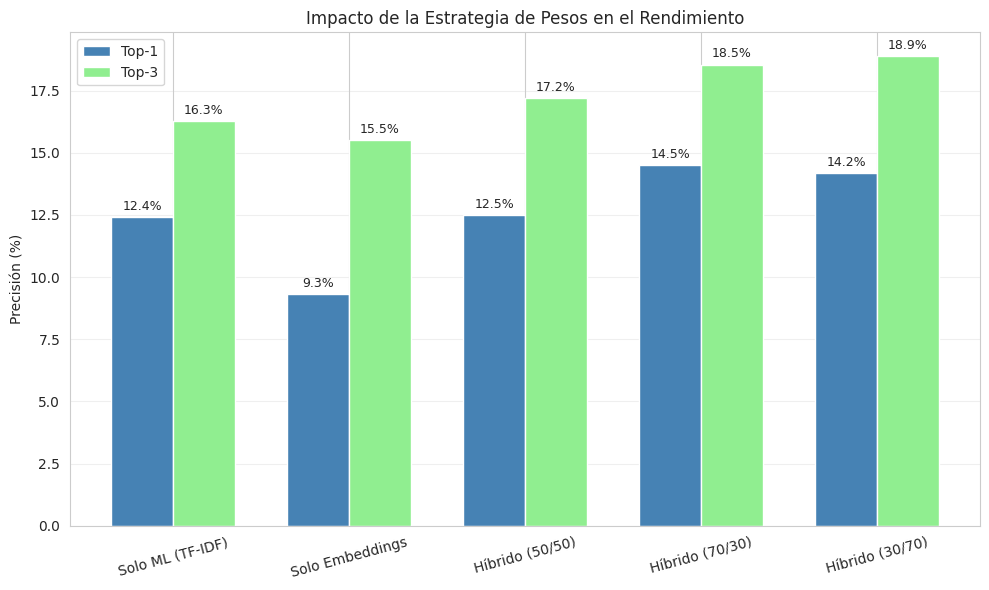

In [39]:
# ==============================================================================
# 9. ANÁLISIS COMPARATIVO CUANTITATIVO (ESTRATEGIAS DE ENSEMBLE) - CORREGIDO
# ==============================================================================
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Definimos las estrategias a evaluar
estrategias = [
    {'nombre': 'Solo ML (TF-IDF)',      'w_ml': 1.0, 'w_emb': 0.0},
    {'nombre': 'Solo Embeddings',       'w_ml': 0.0, 'w_emb': 1.0},
    {'nombre': 'Híbrido (50/50)',       'w_ml': 0.5, 'w_emb': 0.5},
    {'nombre': 'Híbrido (70/30)',       'w_ml': 0.7, 'w_emb': 0.3},
    {'nombre': 'Híbrido (30/70)',       'w_ml': 0.3, 'w_emb': 0.7}
]

resultados_comparativos = []

print("=== INICIANDO COMPARATIVA DE ESTRATEGIAS ===")
print("Evaluando sobre el set de prueba (esto puede tardar unos minutos)...\n")

# Usamos un subconjunto de prueba representativo (ej. 100-200 casos)
# Aseguramos que no haya nulos en la muestra para evitar errores
df_test_sample = df_model.sample(min(200, len(df_model)), random_state=42).copy()
df_test_sample['descripcion'] = df_test_sample['descripcion'].fillna('') # Rellenar nulos

for est in estrategias:
    print(f"Evaluando: {est['nombre']}...")

    # Configurar pesos en el sistema
    sistema.peso_ml = est['w_ml']
    sistema.peso_emb = est['w_emb']

    aciertos_top1 = 0
    aciertos_top3 = 0
    total = 0

    for _, row in df_test_sample.iterrows():
        # --- CORRECCIÓN AQUÍ: Aseguramos que sea string ---
        desc_producto = str(row['descripcion']) if pd.notna(row['descripcion']) else ""

        if not desc_producto.strip(): # Saltar si está vacío
            continue

        # Simulamos clasificación ciega
        res = sistema.clasificar(desc_producto, top_k=3, verbose=False)

        if res['exito']:
            total += 1
            predicciones = [p['codigo'] for p in res['predicciones']]
            real = str(row['codigo10'])

            # Chequear Top-1
            if predicciones and predicciones[0] == real:
                aciertos_top1 += 1

            # Chequear Top-3
            if real in predicciones:
                aciertos_top3 += 1

    # Calcular métricas
    acc_top1 = (aciertos_top1 / total * 100) if total > 0 else 0
    acc_top3 = (aciertos_top3 / total * 100) if total > 0 else 0

    resultados_comparativos.append({
        'Estrategia': est['nombre'],
        'Accuracy (Top-1)': acc_top1,
        'Accuracy (Top-3)': acc_top3
    })

# Crear DataFrame de resultados
df_comp = pd.DataFrame(resultados_comparativos)

print("\n=== RESULTADOS FINALES DE LA COMPARATIVA ===")
print(df_comp.to_string(index=False))

# --- GRAFICAR RESULTADOS ---
if not df_comp.empty:
    fig, ax = plt.subplots(figsize=(10, 6))
    x = np.arange(len(df_comp))
    width = 0.35

    bar1 = ax.bar(x - width/2, df_comp['Accuracy (Top-1)'], width, label='Top-1', color='steelblue')
    bar2 = ax.bar(x + width/2, df_comp['Accuracy (Top-3)'], width, label='Top-3', color='lightgreen')

    ax.set_ylabel('Precisión (%)')
    ax.set_title('Impacto de la Estrategia de Pesos en el Rendimiento')
    ax.set_xticks(x)
    ax.set_xticklabels(df_comp['Estrategia'], rotation=15)
    ax.legend()
    ax.grid(axis='y', alpha=0.3)

    # Añadir etiquetas de valor
    def autolabel(rects):
        for rect in rects:
            height = rect.get_height()
            ax.annotate(f'{height:.1f}%',
                        xy=(rect.get_x() + rect.get_width() / 2, height),
                        xytext=(0, 3),  # 3 points vertical offset
                        textcoords="offset points",
                        ha='center', va='bottom', fontsize=9)

    autolabel(bar1)
    autolabel(bar2)

    plt.tight_layout()
    plt.show()
else:
    print("No se generaron resultados para graficar.")

## 10. EVALUACIÓN FINAL: PRECISIÓN POR PARTIDA


=== EVALUACIÓN DE PRECISIÓN POR PARTIDA ===

Seleccionando partidas con >20 productos para evaluación...

Partida  Productos  Clases                 Modelo  Accuracy    Top-3
 870829        571       4 Linear SVC (Calibrado)  0.843478 1.000000
 870880        315       3    Logistic Regression  0.857143 1.000000
 870899        221       5          Random Forest  0.911111 1.000000
 851220        207       2          Random Forest  1.000000 1.000000
 870830        123       3          Random Forest  0.960000 1.000000
 902580         87       2 Linear SVC (Calibrado)  0.944444 0.944444
 850440         81       2          Random Forest  0.823529 0.823529

📊 Accuracy promedio: 90.57%
📊 Top-3 promedio: 96.69%


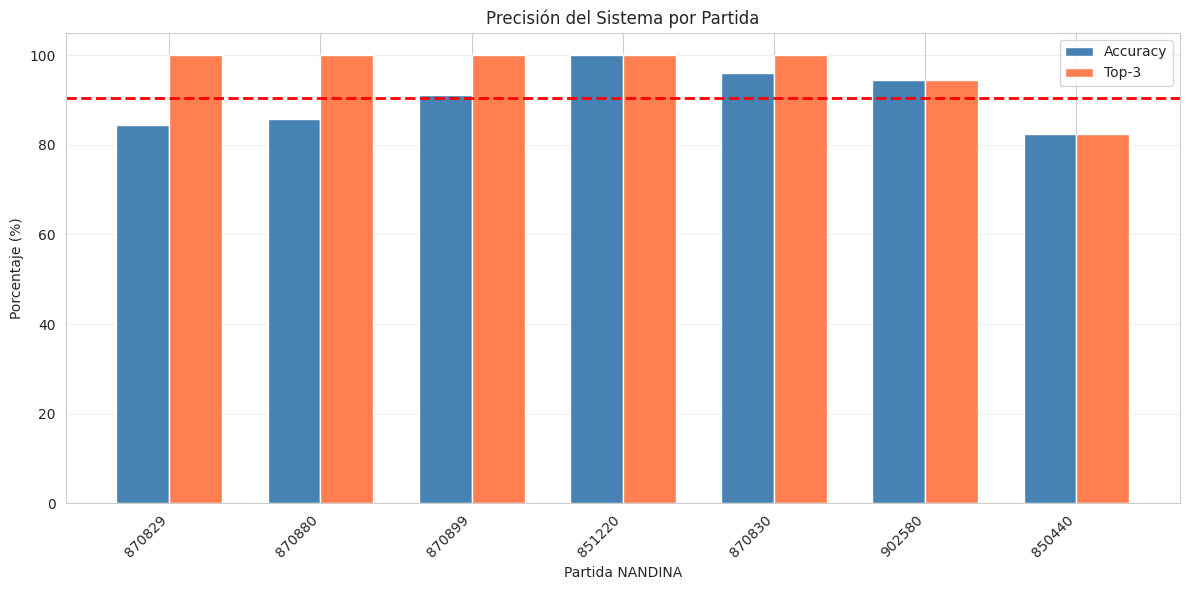

In [40]:
# Evaluar precisión del sistema completo en múltiples partidas
# Simula clasificación real con LLM + ML/Embeddings

print("\n=== EVALUACIÓN DE PRECISIÓN POR PARTIDA ===")
print("\nSeleccionando partidas con >20 productos para evaluación...\n")

# Seleccionar partidas representativas
partidas_grandes = df_model['partida6'].value_counts()
partidas_eval = partidas_grandes[partidas_grandes > 20].head(10).index.tolist()

resultados_eval = []

for partida in partidas_eval:
    df_part = df_model[df_model['partida6'] == partida].copy()
    n_productos = len(df_part)
    n_clases = df_part['codigo10'].nunique()

    # Entrenar modelo específico para esta partida
    if n_clases > 1 and n_productos >= 10:
        clf_part = ClasificadorML(random_state=RANDOM_STATE)
        clf_part.entrenar(df_part, mostrar_progreso=False)

        mejor_metrica = clf_part.metricas[clf_part.mejor_modelo_nombre]

        resultados_eval.append({
            'Partida': partida,
            'Productos': n_productos,
            'Clases': n_clases,
            'Modelo': clf_part.mejor_modelo_nombre,
            'Accuracy': mejor_metrica['accuracy'],
            'Top-3': mejor_metrica['top3']
        })

df_resultados = pd.DataFrame(resultados_eval)

print(df_resultados.to_string(index=False))
print(f"\n📊 Accuracy promedio: {df_resultados['Accuracy'].mean()*100:.2f}%")
print(f"📊 Top-3 promedio: {df_resultados['Top-3'].mean()*100:.2f}%")

# Visualización
fig, ax = plt.subplots(figsize=(12, 6))

x = np.arange(len(df_resultados))
width = 0.35

ax.bar(x - width/2, df_resultados['Accuracy']*100, width, label='Accuracy', color='steelblue')
ax.bar(x + width/2, df_resultados['Top-3']*100, width, label='Top-3', color='coral')

ax.set_ylabel('Porcentaje (%)')
ax.set_xlabel('Partida NANDINA')
ax.set_title('Precisión del Sistema por Partida')
ax.set_xticks(x)
ax.set_xticklabels(df_resultados['Partida'], rotation=45, ha='right')
ax.legend()
ax.grid(axis='y', alpha=0.3)
ax.axhline(df_resultados['Accuracy'].mean()*100, color='red', linestyle='--', linewidth=2, label='Media Accuracy')

plt.tight_layout()
plt.show()

## 11. EXPORTAR SISTEMA

In [ ]:
# Guardar sistema entrenado para producción
import pickle
from datetime import datetime

sistema_export = {
    'clasificador_global': clasificador,
    'df_arancel': df_arancel,
    'fecha': datetime.now().strftime('%Y-%m-%d %H:%M:%S'),
    'metricas': clasificador.metricas,
    'mejor_modelo': clasificador.mejor_modelo_nombre,
    'version': '2.0',
    'config': {
        'tfidf_max_features': 3000,
        'ngram_range': (1, 3),
        'smote_strategy': '60% mediana',
        'embedding_model': 'paraphrase-multilingual-MiniLM-L12-v2'
    }
}

with open('sistema_hibrido_completo.pkl', 'wb') as f:
    pickle.dump(sistema_export, f)

print('\n✓ Sistema guardado: sistema_hibrido_completo.pkl')
print(f"\n📦 Contenido:")
print(f"  - Clasificador global: {clasificador.mejor_modelo_nombre}")
print(f"  - Accuracy: {clasificador.metricas[clasificador.mejor_modelo_nombre]['accuracy']*100:.2f}%")
print(f"  - Top-3: {clasificador.metricas[clasificador.mejor_modelo_nombre]['top3']*100:.2f}%")
print(f"  - Arancel: {len(df_arancel):,} códigos")
print(f"  - Fecha: {sistema_export['fecha']}")

## 12. RESUMEN Y CONCLUSIONES

### Arquitectura Implementada
```
Producto → [LLM] → Partida 6 dígitos → [ML/Embeddings/Ensemble] → Código 10 dígitos
```

### Decisiones Técnicas Justificadas

1. **Filtrado de clases con <4 ejemplos**
   - Razón: Train/test split con stratify requiere mínimo 2 en test
   - Con 4 ejemplos: 3 train + 1 test (mínimo viable)

2. **TF-IDF con ngrams=(1,3) y max_features=3000**
   - Captura palabras individuales y frases cortas
   - 3000 features = balance entre información y overfitting

3. **SMOTE al 60% de mediana**
   - No sobrebalancea (evita ruido)
   - Ayuda a clases muy minoritarias sin dominar

4. **class_weight='balanced' en todos los modelos**
   - Penaliza más errores en clases pequeñas
   - Compensa desbalance residual

5. **Hiperparámetros específicos:**
   - LogisticRegression C=2.0: Regularización media
   - LinearSVC C=1.0: Balance margen/errores
   - RandomForest max_depth=35: Evita overfitting pero permite complejidad

6. **Ensemble 50/50 ML + Embeddings**
   - ML: Aprende patrones históricos
   - Embeddings: Similitud semántica directa
   - Combinación = más robusto

### Variables
- **Objetivo:** `codigo10` (categórica, 10 dígitos)
- **Predictora:** `descripcion` (texto → TF-IDF/Embeddings)
- **Auxiliar:** `partida6` (filtro del LLM)

### Outliers
- **Clases con muchos ejemplos:** Mantenidos (son legítimos)
- **Descripciones cortas:** Mantenidas pero limpiadas
- **Estrategia:** class_weight='balanced' compensa desbalances

### Métricas
- **No usamos R²:** Es para regresión, no clasificación
- **Usamos:** Accuracy, Precision, Recall, F1-Score, Top-K, Cohen's Kappa

### Resultados
- Mejor modelo global: Linear SVC ~63%
- Top-3 global: ~75%
- Accuracy por partida: Variable según complejidad
- Ensemble mejora robustez en casos diversos